In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\EXCEL DATA\Insurance1.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [6]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [9]:
df['children'].value_counts()

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

In [10]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [11]:
df.shape

(1338, 7)

In [12]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [13]:
from sklearn import preprocessing
label_encoder = preprocessing.LabelEncoder()

In [14]:
df['sex'] = label_encoder.fit_transform(df['sex'])
df['smoker'] = label_encoder.fit_transform(df['smoker'])
df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest,10600.54830
1334,18,0,31.920,0,0,northeast,2205.98080
1335,18,0,36.850,0,0,southeast,1629.83350
1336,21,0,25.800,0,0,southwest,2007.94500


<Axes: ylabel='charges'>

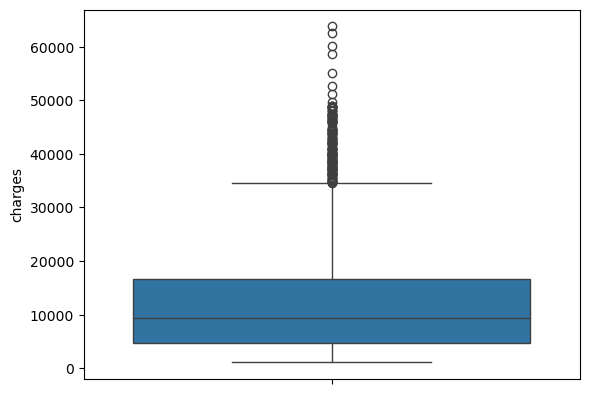

In [15]:
sns.boxplot(df['charges'])

Text(0.5, 1.0, 'The number of smoker and Non-smokers (18 years old)')

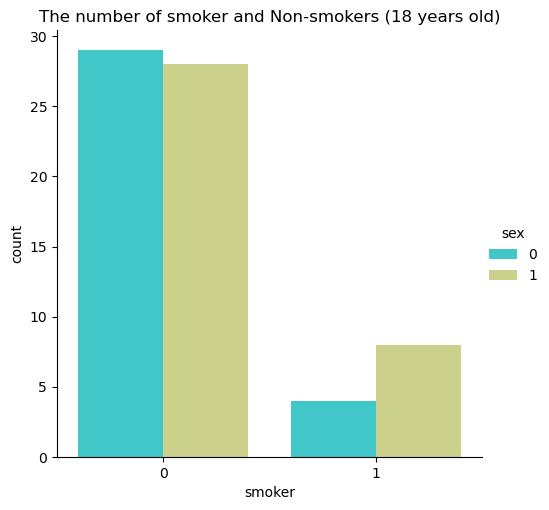

In [16]:
sns.catplot(x="smoker", kind="count", hue='sex', palette="rainbow", data=df[(df.age == 18)])

plt.title("The number of smoker and Non-smokers (18 years old)")

C:\Users\saipr\AppData\Local\Temp\ipykernel_2468\2451496599.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y="smoker", x="charges", data=df[(df.age==18)] , orient="h", palette= 'pink')


<Axes: title={'center': 'charges for 18 year old smokers'}, xlabel='charges', ylabel='smoker'>

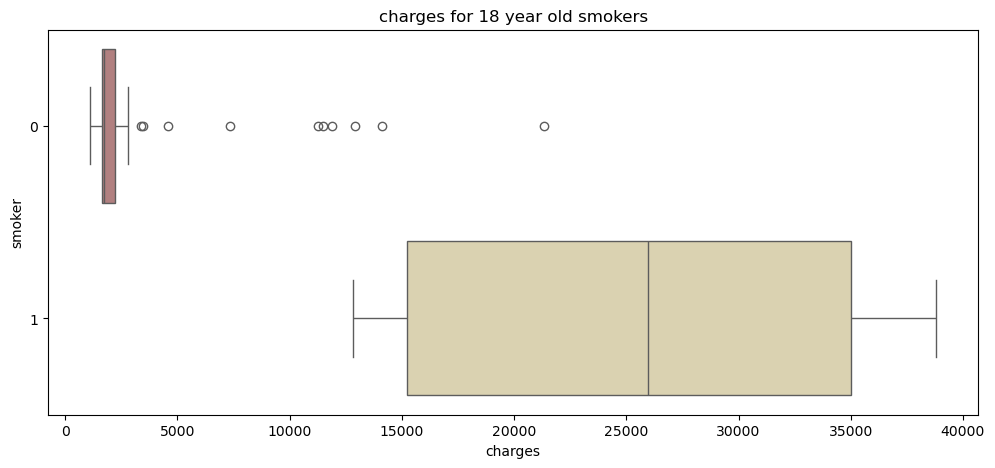

In [17]:
plt.figure(figsize=(12,5))
plt.title("charges for 18 year old smokers")
sns.boxplot(y="smoker", x="charges", data=df[(df.age==18)] , orient="h", palette= 'pink')

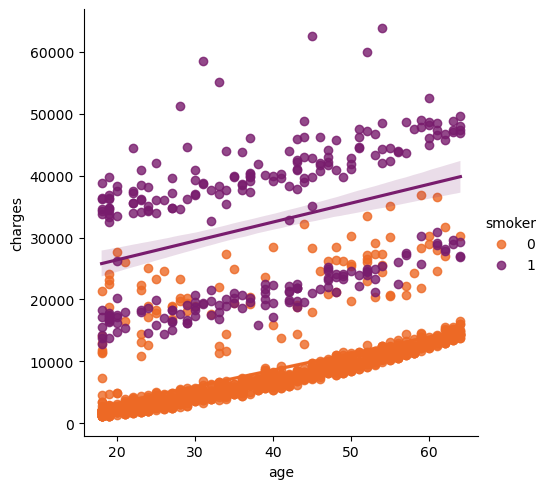

In [18]:
sns.lmplot(x='age', y='charges', hue='smoker',
           data=df, 
           palette = 'inferno_r')

<Axes: xlabel='charges', ylabel='Count'>

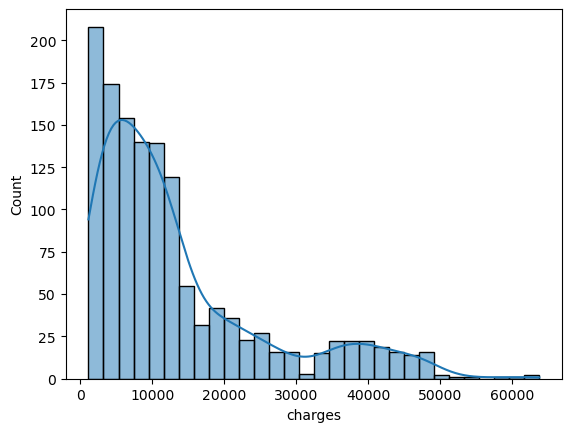

In [19]:
sns.histplot(data=df, x='charges', kde=True)

C:\Users\saipr\AppData\Local\Temp\ipykernel_2468\583450055.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(df['charges'], kde= True, color='c')


Text(0.5, 1.0, 'Distribution of charges')

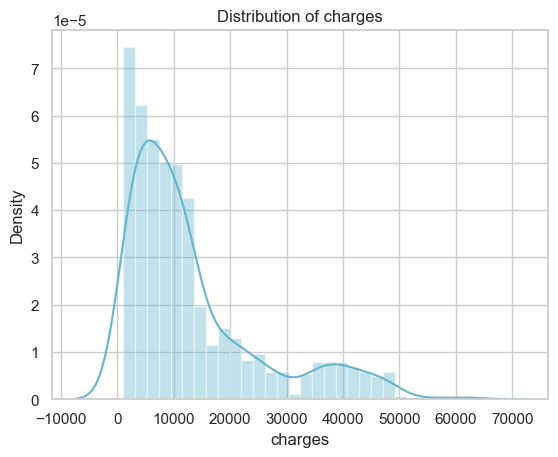

In [20]:
sns.set(style='whitegrid')
ax = sns.distplot(df['charges'], kde= True, color='c')
plt.title('Distribution of charges')

In [21]:
charges = df['charges'].groupby(df['region']).sum().sort_values(ascending=True)
charges = charges.head()
print(charges)

region
southwest    4.012755e+06
northwest    4.035712e+06
northeast    4.343669e+06
southeast    5.363690e+06
Name: charges, dtype: float64


C:\Users\saipr\AppData\Local\Temp\ipykernel_2468\1792947436.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=charges.index, y=charges, palette='Blues')


<Axes: xlabel='region', ylabel='charges'>

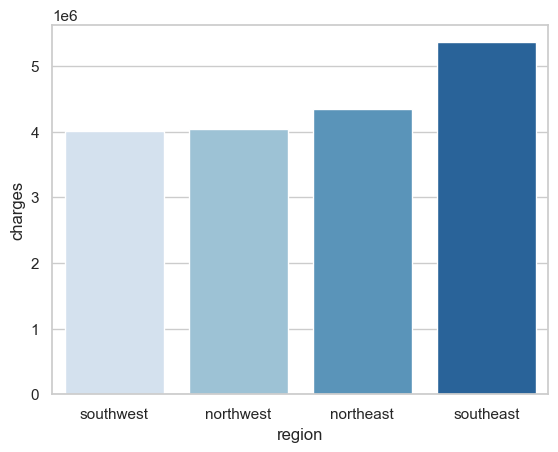

In [22]:
sns.barplot(x=charges.index, y=charges, palette='Blues')

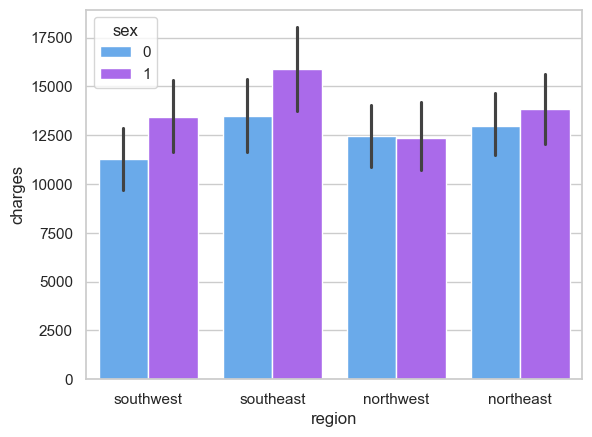

In [23]:
ax = sns.barplot(x='region', y='charges', hue='sex', 
                 data=df, palette='cool')

In [24]:
df['region'] = label_encoder.fit_transform(df['region'])

In [29]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,1,10600.54830
1334,18,0,31.920,0,0,0,2205.98080
1335,18,0,36.850,0,0,2,1629.83350
1336,21,0,25.800,0,0,3,2007.94500


In [25]:
print(label_encoder.classes_)

['northeast' 'northwest' 'southeast' 'southwest']


<Axes: >

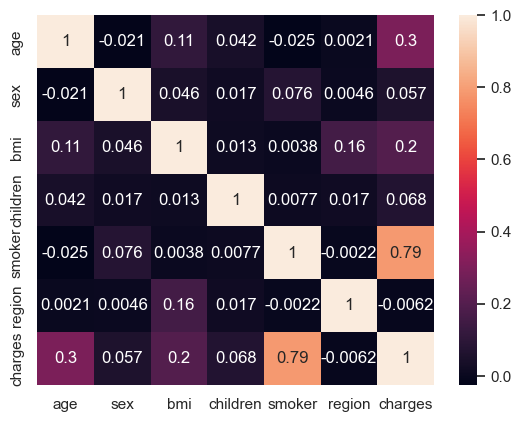

In [26]:
sns.heatmap(df.corr(), annot=True)

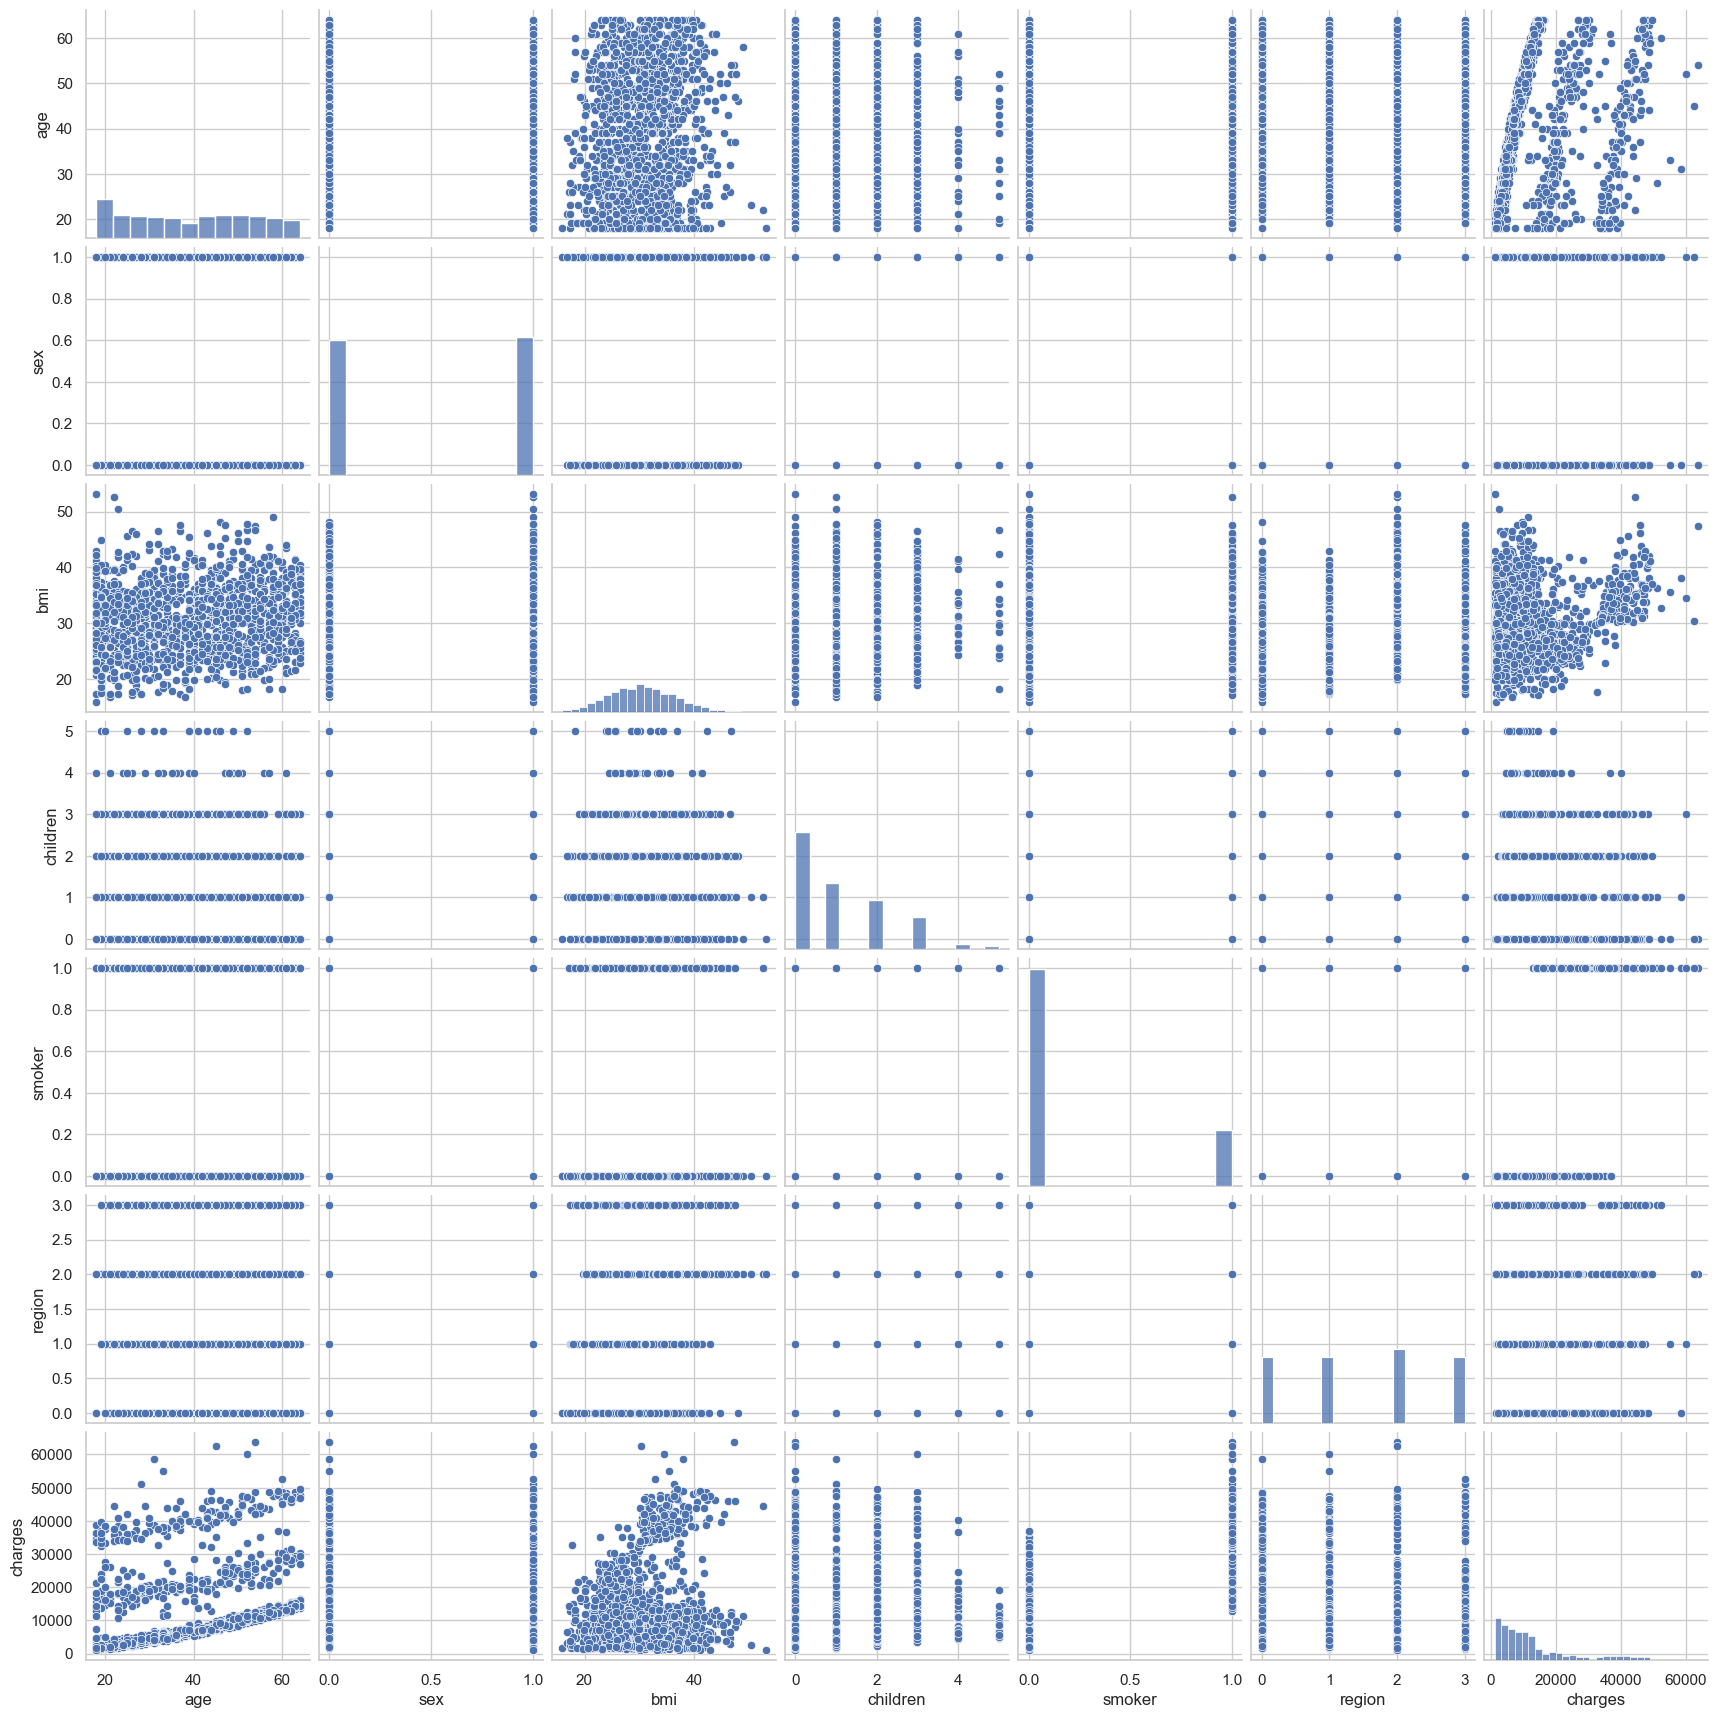

In [27]:
sns.pairplot(df)

In [28]:
from sklearn.model_selection import train_test_split
x = df.drop(['charges'], axis=1)
y = df['charges']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=42)

In [29]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression().fit(x_train, y_train)

y_train_pred = lr.predict(x_train)
y_test_pred =lr.predict(x_test)

print(lr.score(x_test, y_test))
print(lr.score(x_train, y_train))


0.7833463107364538
0.7417049283233981


In [30]:
from sklearn.preprocessing import PolynomialFeatures

X = df.drop(['charges', 'region'], axis=1)
Y = df.charges

quad = PolynomialFeatures (degree = 2)
x_quad = quad.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(x_quad, Y, random_state=0)

plr = LinearRegression().fit(X_train, Y_train)

Y_train_pred = plr.predict(X_train)
Y_test_pred = plr.predict(X_test)

print(lr.score(x_train, y_train))
print(lr.score(x_test, y_test))
print(plr.score(X_test, Y_test))


0.7417049283233981
0.7833463107364538
0.8849197344147236


In [31]:
# COMPARE BETWEEN 2 MODELS

In [32]:
from sklearn.model_selection import train_test_split
x = df.drop(['charges'], axis=1)
y = df['charges']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 42)

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import  GradientBoostingRegressor
from sklearn.tree  import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split


In [34]:
models = {
    "LR" : LinearRegression(),
    "RF" : RandomForestRegressor(n_estimators=100, max_depth=7),
    "DT" : DecisionTreeRegressor(),
    "GradientBoosting" : GradientBoostingRegressor(n_estimators=100, max_depth=7),
    "KNN" : KNeighborsRegressor(),
    "SVR" : SVR()
}

In [35]:
for name, model in models.items():
    print(f'Training models {name} \n')

    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    print(f'Score is {model.score(x_test, y_test)}')

    #Use appropriate regression metrics

    print(f'Training R-squared : {r2_score(y_train, model.predict(x_train))}')
    print(f'Testing R-squared: {r2_score(y_test, y_pred)}')
    print(f'Mean squared Error {mean_squared_error(y_test, y_pred)}')
    print(f'Mean Absolute Error {mean_absolute_error(y_test, y_pred)}')

Training models LR 

Score is 0.7833463107364538
Training R-squared : 0.7417049283233981
Testing R-squared: 0.7833463107364538
Mean squared Error 33635210.43117842
Mean Absolute Error 4186.508898366437
Training models RF 

Score is 0.8717697898236885
Training R-squared : 0.9266081203762779
Testing R-squared: 0.8717697898236885
Mean squared Error 19907577.468795873
Mean Absolute Error 2502.9905158106676
Training models DT 

Score is 0.6941155767067091
Training R-squared : 0.9983078124756305
Testing R-squared: 0.6941155767067091
Mean squared Error 47488168.69937611
Mean Absolute Error 3136.3765177201494
Training models GradientBoosting 

Score is 0.8393653647334441
Training R-squared : 0.9927812965590004
Testing R-squared: 0.8393653647334441
Mean squared Error 24938323.358776502
Mean Absolute Error 2614.7525743436445
Training models KNN 

Score is 0.14450414235747
Training R-squared : 0.39376796951019544
Testing R-squared: 0.14450414235747
Mean squared Error 132814646.69546962
Mean Absol

In [36]:
max_depth_values = [1,2,3,4,5,6,7,8]

train_accuracy_values = []

for max_depth_val in max_depth_values:
    model = RandomForestRegressor(max_depth = max_depth_val, random_state=2)

    model.fit(x_train, y_train)
    y_pred = model.predict(x_train)
    acc_train = model.score(x_test, y_test)
    train_accuracy_values.append(acc_train)

In [37]:
train_accuracy_values

[0.6608048922770777,
 0.8417933495550463,
 0.8675746825596274,
 0.872677170478934,
 0.8753239247794342,
 0.8755309603734038,
 0.8729311378096285,
 0.8711685231482463]

In [38]:
final_model = RandomForestRegressor(max_depth = 6, random_state = 0)
final_model.fit(x_train, y_train)

RandomForestRegressor(max_depth=6, random_state=0)

In [42]:
forest_train_pred = final_model.predict(x_train)
forest_test_pred = final_model.predict(x_test)

print('MSE train data : %.3f, MSE test data :%.3f' % (
mean_squared_error(y_train, forest_train_pred),
mean_squared_error(y_test, forest_test_pred)
))

print('R2 train data: %.3f, R2 test data: %.3f' % (
    r2_score(y_train,forest_train_pred),
    r2_score(y_test, forest_test_pred)
))

MSE train data : 13740918.931, MSE test data :19845744.977
R2 train data: 0.905, R2 test data: 0.872


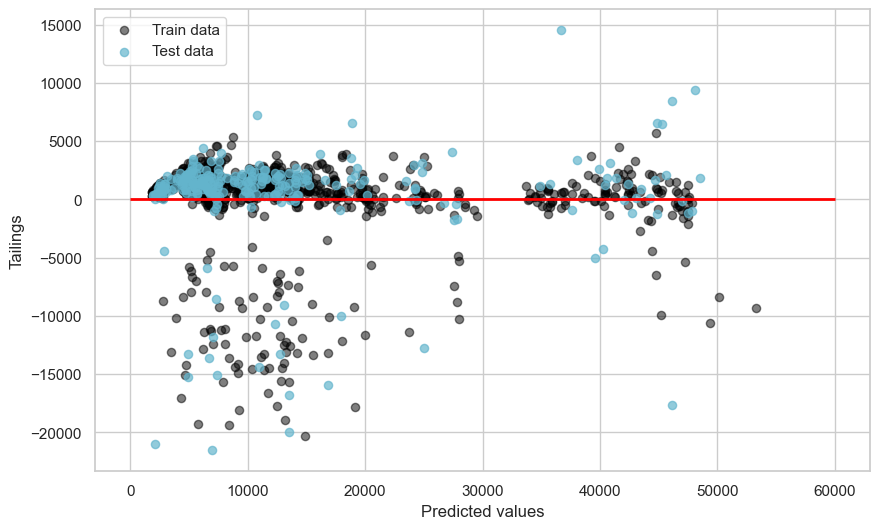

In [41]:
plt.figure(figsize=(10,6))

plt.scatter(forest_train_pred,forest_train_pred - y_train,
          c = 'black', marker = 'o', s = 35, alpha = 0.5,
          label = 'Train data')
plt.scatter(forest_test_pred,forest_test_pred - y_test,
          c = 'c', marker = 'o', s = 35, alpha = 0.7,
          label = 'Test data')
plt.xlabel('Predicted values')
plt.ylabel('Tailings')
plt.legend(loc = 'upper left')
plt.hlines(y = 0, xmin = 0, xmax = 60000, lw = 2, color = 'red')
plt.show()

In [43]:
lr = LinearRegression().fit(x_train, y_train)

y_train_pred = lr.predict(x_train)
y_test_pred = lr.predict(x_test)

print(lr.score(x_test, y_test))


0.7833463107364538


In [44]:
from sklearn.preprocessing import PolynomialFeatures

X = df.drop(['charges', 'region'], axis=1)
Y = df.charges

quad = PolynomialFeatures (degree=2)
x_quad = quad.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(x_quad, Y, random_state=0)

plr = LinearRegression().fit(X_train, Y_train)

y_train_pred = plr.predict(X_train)
y_test_pred = plr.predict(X_test)

print(plr.score(X_test, Y_test))


0.8849197344147236


In [47]:
print(X.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker'], dtype='object')


In [48]:
print(model.n_features_in_)

6


In [50]:
print(x.columns.tolist())

['age', 'sex', 'bmi', 'children', 'smoker', 'region']


In [51]:
print(df['region'].unique())

[3 2 1 0]


In [52]:
import pickle
pickle.dump(model, open("model.pkl", "wb"))